# Задание 2. Методы линейной регрессии и их сравнение

#### 1. Загрузка датасета и вывод на экран

In [12]:
import pandas as pd

# Загрузка датасета
data = pd.read_csv('auto_dataset.csv')

# Вывод первых строк датасета
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


#### 2. Разбиение датасета на train, val, test в соотношении 8:1:1

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Загрузка датасета
data = pd.read_csv('auto_dataset.csv')

# 1. Отделяем 80% данных для обучающей выборки
# Оставшиеся 20% временно складываем в temp
train_data, temp_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

# 2. Делим оставшиеся 20% пополам:
# 10% — validation, 10% — test
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42
)

# Проверяем размеры выборок
print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Train: (800, 10)
Validation: (100, 10)
Test: (100, 10)


#### Вывод первых строк каждой выборки на экран

In [14]:
print("TRAIN:")
display(train_data.head())

print("VALIDATION:")
display(val_data.head())

print("TEST:")
display(test_data.head())

TRAIN:


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
29,audi,a8,limousine,automatik,diesel,ja,232,150000,145,7499
535,volkswagen,golf,limousine,manuell,benzin,nein,75,125000,248,1099
695,ford,fiesta,kleinwagen,manuell,benzin,nein,101,40000,17,12800
557,mercedes_benz,c_klasse,limousine,manuell,benzin,nein,163,100000,190,4200
836,volkswagen,golf,limousine,manuell,benzin,nein,122,150000,96,6199


VALIDATION:


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
411,volkswagen,golf,limousine,automatik,diesel,nein,104,150000,112,7800
621,renault,clio,kleinwagen,manuell,benzin,nein,75,125000,163,1690
721,volkswagen,transporter,bus,automatik,diesel,nein,179,150000,65,29700
914,volkswagen,golf,limousine,automatik,diesel,nein,150,60000,33,19850
917,opel,astra,limousine,manuell,benzin,nein,84,50000,155,2900


TEST:


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
436,renault,clio,kleinwagen,manuell,benzin,nein,58,90000,196,1800
899,audi,a8,limousine,automatik,diesel,nein,232,125000,88,18000
346,mercedes_benz,sl,cabrio,manuell,benzin,nein,185,150000,418,36500
60,volkswagen,golf,limousine,manuell,benzin,nein,265,150000,169,6300
867,toyota,yaris,kleinwagen,manuell,benzin,nein,87,150000,162,1650


#### 2. Кодирование категориальных признаков для всех выборок

In [15]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Целевая переменная
target = 'price'

# Разделяем признаки X и целевую переменную y
X_train_raw = train_data.drop(columns=[target])
y_train = train_data[target].to_numpy()

X_val_raw = val_data.drop(columns=[target])
y_val = val_data[target].to_numpy()

X_test_raw = test_data.drop(columns=[target])
y_test = test_data[target].to_numpy()


# Категориальные признаки
categorical = X_train_raw.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Числовые признаки
numeric = X_train_raw.select_dtypes(
    include=np.number
).columns.tolist()


# Кодирование признаков:
# категориальные -> OneHotEncoder
# числовые -> StandardScaler
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('scaling', StandardScaler(), numeric)
])


# Обучаем преобразования ТОЛЬКО на train
X_train = column_transformer.fit_transform(X_train_raw)

# Для val и test только применяем уже обученные преобразования
X_val = column_transformer.transform(X_val_raw)
X_test = column_transformer.transform(X_test_raw)


# Переводим в обычные numpy-массивы, если результат sparse
if hasattr(X_train, 'toarray'):
    X_train = X_train.toarray()
    X_val = X_val.toarray()
    X_test = X_test.toarray()


# Добавляем столбец единиц для свободного коэффициента b0
X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1))))
X_val = np.hstack((X_val, np.ones((X_val.shape[0], 1))))
X_test = np.hstack((X_test, np.ones((X_test.shape[0], 1))))


# Проверяем размеры
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (800, 195) y_train: (800,)
X_val: (100, 195) y_val: (100,)
X_test: (100, 195) y_test: (100,)


C:\Users\koval\AppData\Local\Temp\ipykernel_2856\1701840569.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = X_train_raw.select_dtypes(


#### 3. Исследование VanillaGradientDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучаем VanillaGradientDescent с шагом lyamda на train, вычисляем R^2_train и Loss_train, запоминаем их;

тестируем VanillaGradientDescent с шагом lyamda на val, вычисляем Loss_val, запоминаем его.

2. Находим лучший шаг lyamda по минимальному Loss_val, назовем его optimal_lyamda.


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score


class VanillaGradientDescent:
    def __init__(self, lyamda, max_iter=1000, tolerance=1e-8):
        self.lyamda = lyamda
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.w = None

    def fit(self, X, y):
        # Начальные веса
        self.w = np.zeros(X.shape[1])

        for k in range(self.max_iter):

            # Градиент MSE
            gradient = (2 / len(y)) * X.T @ (X @ self.w - y)

            # Шаг обучения
            eta_k = self.lyamda / np.sqrt(1 + k)

            # Изменение весов
            delta_w = -eta_k * gradient

            # Обновление весов
            self.w += delta_w

            # Критерий остановки
            if np.sum(delta_w ** 2) < self.tolerance:
                break

        return self

    def predict(self, X):
        return X @ self.w


# 1. Логарифмическая сетка:
# 10^-5, 10^-4, 10^-3, 10^-2, 10^-1, 1
lambda_grid = np.logspace(-5, 0, 6)

results = []


for lyamda in lambda_grid:

    # 1.1. Обучаем VanillaGradientDescent с шагом lyamda на train
    model = VanillaGradientDescent(lyamda=lyamda)

    model.fit(
        X_train,
        y_train
    )

    # Предсказания на train
    y_train_pred = model.predict(X_train)

    # Loss_train
    Loss_train = np.mean(
        (y_train - y_train_pred) ** 2
    )

    # R^2_train
    R2_train = r2_score(
        y_train,
        y_train_pred
    )


    # 1.2. Тестируем модель на validation
    y_val_pred = model.predict(X_val)

    # Loss_val
    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )


    # Запоминаем результаты
    results.append({
        'lyamda': lyamda,
        'R2_train': R2_train,
        'Loss_train': Loss_train,
        'Loss_val': Loss_val
    })


# Таблица всех результатов
results = pd.DataFrame(results)

display(results)


# 2. Находим лучший lyamda по минимальному Loss_val
optimal_lyamda = results.loc[
    results['Loss_val'].idxmin(),
    'lyamda'
]

print("optimal_lyamda =", optimal_lyamda)

,lyamda,R2_train,Loss_train,Loss_val
0,0.00001,-0.786960,1.087587e+08,1.066886e+08
1,0.00010,-0.713080,1.042622e+08,1.021358e+08
2,0.00100,-0.176349,7.159547e+07,6.909842e+07
3,0.01000,0.632378,2.237439e+07,2.211304e+07
4,0.10000,0.705398,1.793020e+07,2.078369e+07
5,1.00000,0.755704,1.486843e+07,1.796623e+07


optimal_lyamda = 1.0


#### 4. Тестирование VanillaGradientDescent с лучшим шагом

Вывод (R_test)^2 и Loss_test.

In [32]:
# Обучаем VanillaGradientDescent с optimal_lyamda
model_test = VanillaGradientDescent(
    lyamda=optimal_lyamda
)

model_test.fit(
    X_train,
    y_train
)

# Тестируем на test
y_test_pred = model_test.predict(X_test)

# Loss_test
Loss_test_vanilla = np.mean(
    (y_test - y_test_pred) ** 2
)

# R^2_test
R2_test_vanilla = r2_score(
    y_test,
    y_test_pred
)

print("optimal_lyamda =", optimal_lyamda)
print("R2_test =", R2_test_vanilla)
print("Loss_test =", Loss_test_vanilla)

optimal_lyamda = 1.0
R2_test = 0.6340036102688498
Loss_test = 25523667.372348256


#### 5. Вывод по VanillaGradientDescent

1. Вычисляем и выводим: optima_lyamda, loss_train (для optimal_lyamda), loss_test, r^2_train (для optimal_lyamda), число итераций на val;

2. Отображаем график зависимости Loss_val для лучшего шага от числа итераций.

optimal_lyamda = 1.0
Loss_train = 14868426.385648627
Loss_test = 25523667.372348256
R2_train = 0.7557043204653969
Число итераций на val = 1000


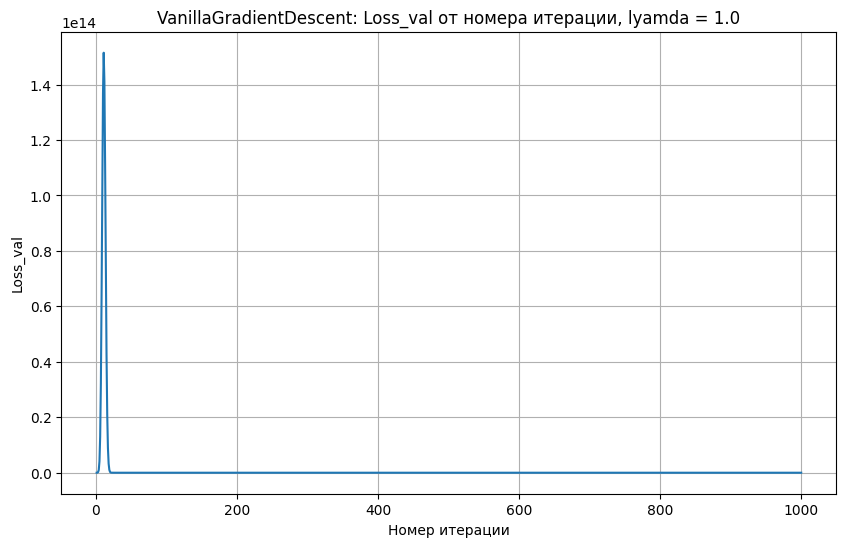

In [33]:
import matplotlib.pyplot as plt


# Находим результаты на train для optimal_lyamda
best_row = results.loc[
    results['lyamda'] == optimal_lyamda
].iloc[0]

Loss_train_optimal = best_row['Loss_train']
R2_train_optimal = best_row['R2_train']


# Обучаем модель с optimal_lyamda и сохраняем Loss_val
model_optimal = VanillaGradientDescent(
    lyamda=optimal_lyamda
)

model_optimal.w = np.zeros(X_train.shape[1])

Loss_val_history = []

for k in range(model_optimal.max_iter):

    # Градиент на train
    gradient = (
        (2 / len(y_train))
        * X_train.T
        @ (X_train @ model_optimal.w - y_train)
    )

    # Шаг
    eta_k = optimal_lyamda / np.sqrt(1 + k)

    # Обновление весов
    delta_w = -eta_k * gradient
    model_optimal.w += delta_w

    # Loss на validation после текущей итерации
    y_val_pred = model_optimal.predict(X_val)

    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )

    Loss_val_history.append(Loss_val)

    # Критерий остановки
    if np.sum(delta_w ** 2) < model_optimal.tolerance:
        break


# 4. Выводим результаты
print("optimal_lyamda =", optimal_lyamda)
print("Loss_train =", Loss_train_optimal)
print("Loss_test =", Loss_test_vanilla)
print("R2_train =", R2_train_optimal)
print("Число итераций на val =", len(Loss_val_history))


# 5. График Loss_val для optimal_lyamda от номера итерации
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(Loss_val_history) + 1),
    Loss_val_history
)

plt.xlabel("Номер итерации")
plt.ylabel("Loss_val")
plt.title(
    f"VanillaGradientDescent: Loss_val от номера итерации, "
    f"lyamda = {optimal_lyamda}"
)

plt.grid(True)
plt.show()

#### 6. Исследование StochasticGradientDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучаем StochasticGradientDescent с шагом lyamda на train, вычисляем R_train ^ 2 и Loss_train, запоминаем их;

тестируем StochasticGradientDescent с шагом lyamda на val, вычисляем Loss_val, запоминаем его.

2. Находим лучший шаг lyamda по минимальному Loss_val, назовем его optimal_lyamda.

In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score


class StochasticGradientDescent:
    def __init__(
        self,
        lyamda,
        batch_size=32,
        max_iter=1000,
        tolerance=1e-6
    ):
        self.lyamda = lyamda
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.w = None

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])

        n = X.shape[0]

        for k in range(self.max_iter):

            # Случайный батч с повторениями
            batch_indices = np.random.randint(
                0,
                n,
                size=self.batch_size
            )

            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            # Градиент MSE по батчу
            gradient = (
                2 / self.batch_size
            ) * X_batch.T @ (
                X_batch @ self.w - y_batch
            )

            # TimeDecayLR
            eta_k = self.lyamda / np.sqrt(1 + k)

            # Изменение весов
            delta_w = -eta_k * gradient

            # Обновление весов
            self.w += delta_w

            # Критерий остановки
            if np.sum(delta_w ** 2) < self.tolerance:
                break

        return self

    def predict(self, X):
        return X @ self.w


# 1. Логарифмическая сетка:
# 10^-5, 10^-4, 10^-3, 10^-2, 10^-1, 1
lambda_grid = np.logspace(-5, 0, 6)

results_sgd = []


for lyamda in lambda_grid:

    # 1.1. Обучаем StochasticGradientDescent на train
    model = StochasticGradientDescent(
        lyamda=lyamda
    )

    model.fit(
        X_train,
        y_train
    )

    # Предсказания на train
    y_train_pred = model.predict(X_train)

    # Loss_train
    Loss_train = np.mean(
        (y_train - y_train_pred) ** 2
    )

    # R^2_train
    R2_train = r2_score(
        y_train,
        y_train_pred
    )

    # 1.2. Тестируем на validation
    y_val_pred = model.predict(X_val)

    # Loss_val
    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )

    # Запоминаем результаты
    results_sgd.append({
        'lyamda': lyamda,
        'R2_train': R2_train,
        'Loss_train': Loss_train,
        'Loss_val': Loss_val
    })


# Таблица результатов
results_sgd = pd.DataFrame(results_sgd)

display(results_sgd)


# 2. Находим лучший lyamda по минимальному Loss_val
optimal_lyamda = results_sgd.loc[
    results_sgd['Loss_val'].idxmin(),
    'lyamda'
]

print("optimal_lyamda =", optimal_lyamda)

,lyamda,R2_train,Loss_train,Loss_val
0,0.00001,-0.787009,1.087617e+08,1.066915e+08
1,0.00010,-0.712389,1.042202e+08,1.020906e+08
2,0.00100,-0.180399,7.184197e+07,6.931928e+07
3,0.01000,0.625520,2.279175e+07,2.231319e+07
4,0.10000,0.704811,1.796592e+07,2.061132e+07
5,1.00000,-47.103102,2.927671e+09,3.389962e+09


optimal_lyamda = 0.1


#### 7. Тестирование StochasticGradientDescent с лучшим шагом

Вычисление и вывод (R_test)^2 и Loss_test.

In [34]:
# Обучаем StochasticGradientDescent с optimal_lyamda
model_test_sgd = StochasticGradientDescent(
    lyamda=optimal_lyamda
)

model_test_sgd.fit(
    X_train,
    y_train
)

# Тестируем на test
y_test_pred = model_test_sgd.predict(X_test)

# R^2_test
R2_test_sgd = r2_score(
    y_test,
    y_test_pred
)

# Loss_test
Loss_test_sgd = np.mean(
    (y_test - y_test_pred) ** 2
)

print("R2_test =", R2_test_sgd)
print("Loss_test =", Loss_test_sgd)

R2_test = -46.69548883392092
Loss_test = 3326163389.3514256


#### 8. Вывод по StochasticGradientDescent:

1. Вычисляем и выводим optimal_lyamda, loss_train (для optimal_lyamda), loss_test, r^2_train (для optimal_lyamda), число итераций на val;

2. Отображаем график зависимости Loss_val для лучшего шага от номера итерации k.

optimal_lyamda = 1.0
Loss_train = 2927671241.522809
Loss_test = 3326163389.3514256
R2_train = -47.10310229548402
Число итераций на val = 1000


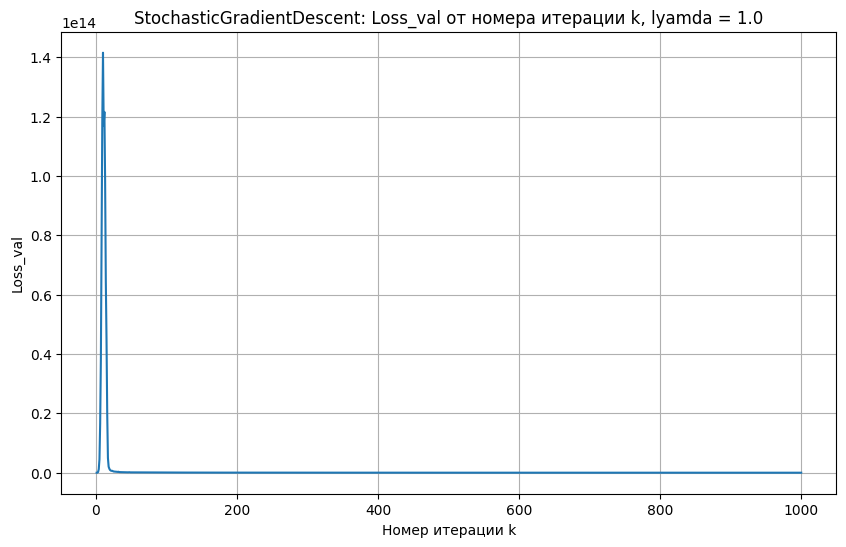

In [35]:
import matplotlib.pyplot as plt


# Результаты на train для optimal_lyamda
best_row = results_sgd.loc[
    results_sgd['lyamda'] == optimal_lyamda
].iloc[0]

Loss_train_optimal = best_row['Loss_train']
R2_train_optimal = best_row['R2_train']


# Обучаем StochasticGradientDescent с optimal_lyamda
# и сохраняем Loss_val на каждой итерации k
model_optimal_sgd = StochasticGradientDescent(
    lyamda=optimal_lyamda
)

model_optimal_sgd.w = np.zeros(X_train.shape[1])

Loss_val_history_sgd = []

n = X_train.shape[0]


for k in range(model_optimal_sgd.max_iter):

    # Случайный батч
    batch_indices = np.random.randint(
        0,
        n,
        size=model_optimal_sgd.batch_size
    )

    X_batch = X_train[batch_indices]
    y_batch = y_train[batch_indices]

    # Градиент MSE по батчу
    gradient = (
        2 / model_optimal_sgd.batch_size
    ) * X_batch.T @ (
        X_batch @ model_optimal_sgd.w - y_batch
    )

    # TimeDecayLR
    eta_k = optimal_lyamda / np.sqrt(1 + k)

    # Обновление весов
    delta_w = -eta_k * gradient

    model_optimal_sgd.w += delta_w

    # Loss_val на итерации k
    y_val_pred = model_optimal_sgd.predict(X_val)

    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )

    Loss_val_history_sgd.append(Loss_val)

    # Критерий остановки
    if np.sum(delta_w ** 2) < model_optimal_sgd.tolerance:
        break


# 4. Выводим результаты
print("optimal_lyamda =", optimal_lyamda)
print("Loss_train =", Loss_train_optimal)
print("Loss_test =", Loss_test_sgd)
print("R2_train =", R2_train_optimal)
print("Число итераций на val =", len(Loss_val_history_sgd))


# 5. График Loss_val для optimal_lyamda
# от номера итерации k

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(Loss_val_history_sgd) + 1),
    Loss_val_history_sgd
)

plt.xlabel("Номер итерации k")
plt.ylabel("Loss_val")

plt.title(
    f"StochasticGradientDescent: Loss_val от номера итерации k, "
    f"lyamda = {optimal_lyamda}"
)

plt.grid(True)
plt.show()

#### 9. Исследование SAGDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучаем SAGDescent с шагом lyamda на train, вычисляем R_train ^ 2 и Loss_train, запоминаем их;

тестируем SAGDescent с шагом lyamda на val, вычисляем Loss_val, запоминаем его.

2. Находим лучший шаг lyamda по минимальному Loss_val, назовем его optimal_lyamda.


In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score


class SAGDescent:
    def __init__(
        self,
        lyamda,
        max_iter=1000,
        tolerance=1e-6
    ):
        self.lyamda = lyamda
        self.max_iter = max_iter
        self.tolerance = tolerance

        self.w = None
        self.grad_memory = None
        self.avg_grad = None

    def fit(self, X, y):

        n = X.shape[0]
        d = X.shape[1]

        # Начальные веса
        self.w = np.zeros(d)

        # Память последних градиентов объектов
        self.grad_memory = {}

        # Среднее запомненных градиентов
        self.avg_grad = np.zeros(d)

        for k in range(self.max_iter):

            # Случайно выбираем один объект
            j = np.random.randint(0, n)

            X_j = X[j:j + 1]
            y_j = y[j]

            # Предсказание для выбранного объекта
            prediction = np.asarray(
                X_j @ self.w
            ).ravel()[0]

            # Новый индивидуальный градиент
            new_gradient = (
                2 * (prediction - y_j) * X_j.T
            )

            # Если X — sparse-матрица
            if hasattr(new_gradient, "toarray"):
                new_gradient = new_gradient.toarray().ravel()
            else:
                new_gradient = np.asarray(new_gradient).ravel()

            # Старый градиент этого объекта
            old_gradient = self.grad_memory.get(
                j,
                np.zeros(d)
            )

            # Обновляем средний градиент SAG
            self.avg_grad += (
                new_gradient - old_gradient
            ) / n

            # Запоминаем новый градиент объекта j
            self.grad_memory[j] = new_gradient

            # TimeDecayLR
            eta_k = self.lyamda / np.sqrt(1 + k)

            # Изменение весов
            delta_w = -eta_k * self.avg_grad

            # Обновление весов
            self.w += delta_w

            # Критерий остановки
            if np.sum(delta_w ** 2) < self.tolerance:
                break

        return self

    def predict(self, X):
        return X @ self.w


# 1. Логарифмическая сетка:
# 10^-5, 10^-4, 10^-3, 10^-2, 10^-1, 1
lambda_grid = np.logspace(-5, 0, 6)

results_sag = []


for lyamda in lambda_grid:

    # 1.1. Обучаем SAGDescent на train
    model = SAGDescent(
        lyamda=lyamda
    )

    model.fit(
        X_train,
        y_train
    )

    # Предсказания на train
    y_train_pred = model.predict(X_train)

    # Loss_train
    Loss_train = np.mean(
        (y_train - y_train_pred) ** 2
    )

    # R^2_train
    R2_train = r2_score(
        y_train,
        y_train_pred
    )

    # 1.2. Тестируем на validation
    y_val_pred = model.predict(X_val)

    # Loss_val
    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )

    # Запоминаем результаты
    results_sag.append({
        'lyamda': lyamda,
        'R2_train': R2_train,
        'Loss_train': Loss_train,
        'Loss_val': Loss_val
    })


# Таблица результатов
results_sag = pd.DataFrame(results_sag)

display(results_sag)


# 2. Находим лучший lyamda по минимальному Loss_val
optimal_lyamda = results_sag.loc[
    results_sag['Loss_val'].idxmin(),
    'lyamda'
]

print("optimal_lyamda =", optimal_lyamda)

,lyamda,R2_train,Loss_train,Loss_val
0,0.00001,-0.795457,1.092759e+08,1.072123e+08
1,0.00010,-0.769162,1.076755e+08,1.055889e+08
2,0.00100,-0.579179,9.611266e+07,9.387078e+07
3,0.01000,0.508965,2.988558e+07,2.780158e+07
4,0.10000,0.515520,2.948664e+07,3.387934e+07
5,1.00000,0.351539,3.946694e+07,4.961593e+07


optimal_lyamda = 0.01


#### 10. Тестирование SAGDescent с наилучшим lyamda

Вычисляем и выводим (R_test)^2 и Loss_test

In [36]:
# Обучаем SAGDescent с optimal_lyamda
model_test_sag = SAGDescent(
    lyamda=optimal_lyamda
)

model_test_sag.fit(
    X_train,
    y_train
)

# Тестируем на test
y_test_pred = model_test_sag.predict(X_test)

# R^2_test
R2_test_sag = r2_score(
    y_test,
    y_test_pred
)

# Loss_test
Loss_test_sag = np.mean(
    (y_test - y_test_pred) ** 2
)

print("R2_test =", R2_test_sag)
print("Loss_test =", Loss_test_sag)

R2_test = 0.46492334391518986
Loss_test = 37314899.74163182


#### 11. Вывод по SAGDescent:

1. Вычисляем и выводим optima_lyamda, loss_train (для optimal_lyamda), loss_test, r^2_train (для optimal_lyamda), число итераций на val;

2. Отображаем график зависимости Loss_val для optimal_lyamda от номера итерации k.

optimal_lyamda = 1.0
Loss_train = 39466935.53052858
Loss_test = 37314899.74163182
R2_train = 0.3515385162827208
Число итераций на val = 1000


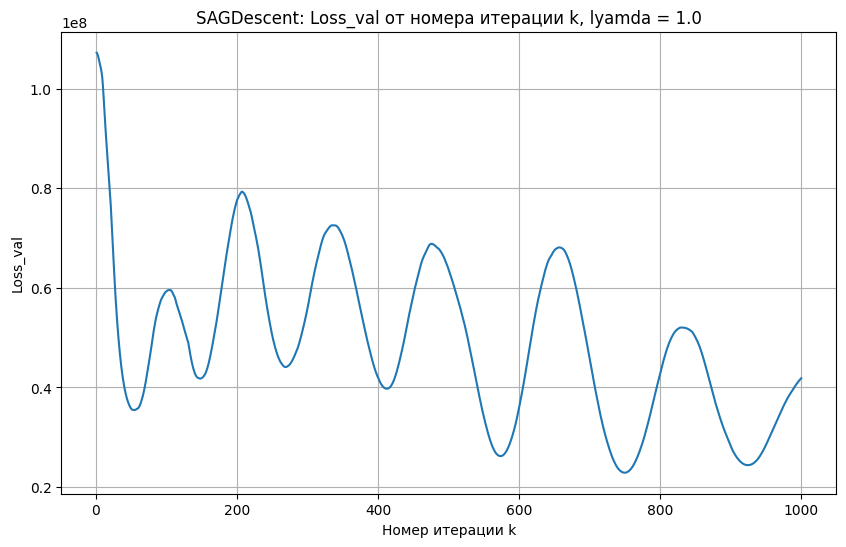

In [37]:
import matplotlib.pyplot as plt


# Результаты на train для optimal_lyamda
best_row = results_sag.loc[
    results_sag['lyamda'] == optimal_lyamda
].iloc[0]

Loss_train_optimal = best_row['Loss_train']
R2_train_optimal = best_row['R2_train']


# Обучаем SAGDescent с optimal_lyamda
# и сохраняем Loss_val на каждой итерации k
model_optimal_sag = SAGDescent(
    lyamda=optimal_lyamda
)

n = X_train.shape[0]
d = X_train.shape[1]

model_optimal_sag.w = np.zeros(d)
model_optimal_sag.grad_memory = {}
model_optimal_sag.avg_grad = np.zeros(d)

Loss_val_history_sag = []


for k in range(model_optimal_sag.max_iter):

    # Случайно выбираем один объект
    j = np.random.randint(0, n)

    X_j = X_train[j:j + 1]
    y_j = y_train[j]

    # Предсказание для выбранного объекта
    prediction = np.asarray(
        X_j @ model_optimal_sag.w
    ).ravel()[0]

    # Новый индивидуальный градиент
    new_gradient = (
        2 * (prediction - y_j) * X_j.T
    )

    if hasattr(new_gradient, "toarray"):
        new_gradient = new_gradient.toarray().ravel()
    else:
        new_gradient = np.asarray(new_gradient).ravel()

    # Старый сохранённый градиент объекта
    old_gradient = model_optimal_sag.grad_memory.get(
        j,
        np.zeros(d)
    )

    # Обновляем средний градиент SAG
    model_optimal_sag.avg_grad += (
        new_gradient - old_gradient
    ) / n

    # Запоминаем новый градиент
    model_optimal_sag.grad_memory[j] = new_gradient

    # TimeDecayLR
    eta_k = optimal_lyamda / np.sqrt(1 + k)

    # Изменение весов
    delta_w = -eta_k * model_optimal_sag.avg_grad

    # Обновление весов
    model_optimal_sag.w += delta_w

    # Loss_val на итерации k
    y_val_pred = model_optimal_sag.predict(X_val)

    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )

    Loss_val_history_sag.append(Loss_val)

    # Критерий остановки
    if np.sum(delta_w ** 2) < model_optimal_sag.tolerance:
        break


# 4. Выводим результаты
print("optimal_lyamda =", optimal_lyamda)
print("Loss_train =", Loss_train_optimal)
print("Loss_test =", Loss_test_sag)
print("R2_train =", R2_train_optimal)
print("Число итераций на val =", len(Loss_val_history_sag))


# 5. График Loss_val для optimal_lyamda
# от номера итерации k
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(Loss_val_history_sag) + 1),
    Loss_val_history_sag
)

plt.xlabel("Номер итерации k")
plt.ylabel("Loss_val")

plt.title(
    f"SAGDescent: Loss_val от номера итерации k, "
    f"lyamda = {optimal_lyamda}"
)

plt.grid(True)
plt.show()

#### 12. Исследование MomentumDescent

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучаем MomentumDescent с шагом lyamda на train, вычисляем R_train ^ 2 и Loss_train, запоминаем их;

тестируем MomentumDescent с шагом lyamda на val, вычисляем Loss_val, запоминаем его.

2. Находим лучший шаг lyamda по минимальному Loss_val

In [25]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score


class MomentumDescent:
    def __init__(
        self,
        lyamda,
        alpha=0.9,
        max_iter=1000,
        tolerance=1e-6
    ):
        self.lyamda = lyamda
        self.alpha = alpha
        self.max_iter = max_iter
        self.tolerance = tolerance

        self.w = None
        self.h = None

    def fit(self, X, y):

        self.w = np.zeros(X.shape[1])

        # h_0 = 0
        self.h = np.zeros(X.shape[1])

        for k in range(self.max_iter):

            # Полный градиент MSE
            gradient = (
                2 / len(y)
            ) * X.T @ (
                X @ self.w - y
            )

            # TimeDecayLR
            eta_k = self.lyamda / np.sqrt(1 + k)

            # h_{k+1} = alpha * h_k + eta_k * gradient
            self.h = (
                self.alpha * self.h
                + eta_k * gradient
            )

            # w_{k+1} - w_k = -h_{k+1}
            delta_w = -self.h

            # Обновляем веса
            self.w += delta_w

            # Критерий остановки
            if np.sum(delta_w ** 2) < self.tolerance:
                break

        return self

    def predict(self, X):
        return X @ self.w


# 1. Логарифмическая сетка:
# 10^-5, 10^-4, 10^-3, 10^-2, 10^-1, 1
lambda_grid = np.logspace(-5, 0, 6)

results_momentum = []


for lyamda in lambda_grid:

    # 1.1. Обучаем MomentumDescent на train
    model = MomentumDescent(
        lyamda=lyamda
    )

    model.fit(
        X_train,
        y_train
    )

    # Предсказания на train
    y_train_pred = model.predict(X_train)

    # Loss_train
    Loss_train = np.mean(
        (y_train - y_train_pred) ** 2
    )

    # R^2_train
    R2_train = r2_score(
        y_train,
        y_train_pred
    )

    # 1.2. Тестируем на validation
    y_val_pred = model.predict(X_val)

    # Loss_val
    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )

    # Запоминаем результаты
    results_momentum.append({
        'lyamda': lyamda,
        'R2_train': R2_train,
        'Loss_train': Loss_train,
        'Loss_val': Loss_val
    })


# Таблица результатов
results_momentum = pd.DataFrame(
    results_momentum
)

display(results_momentum)


# 2. Находим лучший lyamda по минимальному Loss_val
optimal_lyamda = results_momentum.loc[
    results_momentum['Loss_val'].idxmin(),
    'lyamda'
]

print("optimal_lyamda =", optimal_lyamda)

,lyamda,R2_train,Loss_train,Loss_val
0,0.00001,-0.713410,1.042823e+08,1.021561e+08
1,0.00010,-0.176435,7.160070e+07,6.910218e+07
2,0.00100,0.633931,2.227983e+07,2.204509e+07
3,0.01000,0.705435,1.792795e+07,2.078933e+07
4,0.10000,0.755792,1.486309e+07,1.795768e+07
5,1.00000,0.794371,1.251507e+07,1.671836e+07


optimal_lyamda = 1.0


#### 13. Тестирование MomentumDescent с наилучшим lyamda

Вычисление и вывод (R_test)^2 и Loss_test

In [38]:
# Обучаем MomentumDescent с optimal_lyamda
model_test_momentum = MomentumDescent(
    lyamda=optimal_lyamda
)

model_test_momentum.fit(
    X_train,
    y_train
)

# Тестируем на test
y_test_pred = model_test_momentum.predict(X_test)

# R^2_test
R2_test_momentum = r2_score(
    y_test,
    y_test_pred
)

# Loss_test
Loss_test_momentum = np.mean(
    (y_test - y_test_pred) ** 2
)

print("R2_test =", R2_test_momentum)
print("Loss_test =", Loss_test_momentum)

R2_test = 0.597391109433322
Loss_test = 28076931.063507285


#### 14. Вывод по MomentumDescent

1. Вычисляем и выводим optima_lyamda, loss_train (для optimal_lyamda), loss_test, r^2_train (для optimal_lyamda), число итераций на val;

2. Отображаем график зависимости Loss_val для optimal_lyamda от номера итерации.

optimal_lyamda = 1.0
Loss_train = 12515069.99453256
Loss_test = 28076931.063507285
R2_train = 0.7943711426187973
Число итераций на val = 1000


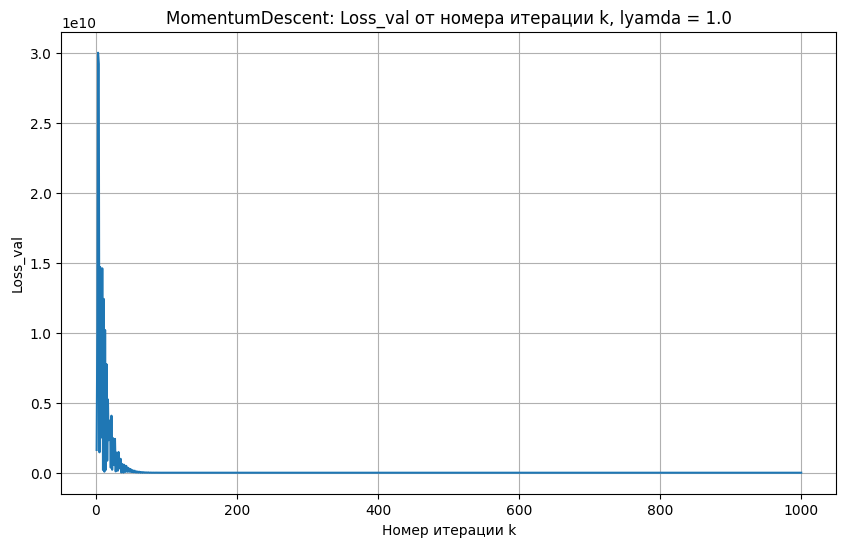

In [39]:
import matplotlib.pyplot as plt


# Результаты на train для optimal_lyamda
best_row = results_momentum.loc[
    results_momentum['lyamda'] == optimal_lyamda
].iloc[0]

Loss_train_optimal = best_row['Loss_train']
R2_train_optimal = best_row['R2_train']


# Обучаем MomentumDescent с optimal_lyamda
# и сохраняем Loss_val на каждой итерации k
model_optimal_momentum = MomentumDescent(
    lyamda=optimal_lyamda
)

model_optimal_momentum.w = np.zeros(X_train.shape[1])

# h_0 = 0
model_optimal_momentum.h = np.zeros(X_train.shape[1])

Loss_val_history_momentum = []


for k in range(model_optimal_momentum.max_iter):

    # Полный градиент MSE
    gradient = (
        2 / len(y_train)
    ) * X_train.T @ (
        X_train @ model_optimal_momentum.w - y_train
    )

    # TimeDecayLR
    eta_k = optimal_lyamda / np.sqrt(1 + k)

    # h_{k+1} = alpha * h_k + eta_k * gradient
    model_optimal_momentum.h = (
        model_optimal_momentum.alpha
        * model_optimal_momentum.h
        + eta_k * gradient
    )

    # w_{k+1} - w_k = -h_{k+1}
    delta_w = -model_optimal_momentum.h

    # Обновление весов
    model_optimal_momentum.w += delta_w

    # Loss_val на итерации k
    y_val_pred = model_optimal_momentum.predict(X_val)

    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )

    Loss_val_history_momentum.append(Loss_val)

    # Критерий остановки
    if np.sum(delta_w ** 2) < model_optimal_momentum.tolerance:
        break


# 4. Выводим результаты
print("optimal_lyamda =", optimal_lyamda)
print("Loss_train =", Loss_train_optimal)
print("Loss_test =", Loss_test_momentum)
print("R2_train =", R2_train_optimal)
print("Число итераций на val =", len(Loss_val_history_momentum))


# 5. График Loss_val для optimal_lyamda
# от номера итерации k
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(Loss_val_history_momentum) + 1),
    Loss_val_history_momentum
)

plt.xlabel("Номер итерации k")
plt.ylabel("Loss_val")

plt.title(
    f"MomentumDescent: Loss_val от номера итерации k, "
    f"lyamda = {optimal_lyamda}"
)

plt.grid(True)
plt.show()

#### 15. Исследование Adam

1. Для каждого шага lyamda в логарифмической сетке: 10^-5, … , 1:

обучаем Adam с шагом lyamda на train, вычисляем R_train ^ 2 и Loss_train, запоминаем их;

тестируем Adam с шагом lyamda на val, вычисляем Loss_val, запоминаем его.

2. Находим лучший шаг lyamda по минимальному Loss_val.

In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score


class Adam:
    def __init__(
        self,
        lyamda,
        beta_1=0.9,
        beta_2=0.999,
        eps=1e-8,
        max_iter=1000,
        tolerance=1e-6
    ):
        self.lyamda = lyamda
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.eps = eps
        self.max_iter = max_iter
        self.tolerance = tolerance

        self.w = None
        self.m = None
        self.v = None

    def fit(self, X, y):

        self.w = np.zeros(X.shape[1])

        # m_0 = 0
        self.m = np.zeros(X.shape[1])

        # v_0 = 0
        self.v = np.zeros(X.shape[1])

        for k in range(self.max_iter):

            # Полный градиент MSE
            gradient = (
                2 / len(y)
            ) * X.T @ (
                X @ self.w - y
            )

            # Первый момент
            self.m = (
                self.beta_1 * self.m
                + (1 - self.beta_1) * gradient
            )

            # Второй момент
            self.v = (
                self.beta_2 * self.v
                + (1 - self.beta_2) * gradient ** 2
            )

            # Коррекция смещения
            m_hat = self.m / (
                1 - self.beta_1 ** (k + 1)
            )

            v_hat = self.v / (
                1 - self.beta_2 ** (k + 1)
            )

            # TimeDecayLR
            eta_k = self.lyamda / np.sqrt(1 + k)

            # Изменение весов
            delta_w = (
                -eta_k
                * m_hat
                / (np.sqrt(v_hat) + self.eps)
            )

            # Обновление весов
            self.w += delta_w

            # Критерий остановки
            if np.sum(delta_w ** 2) < self.tolerance:
                break

        return self

    def predict(self, X):
        return X @ self.w


# 1. Логарифмическая сетка:
# 10^-5, 10^-4, 10^-3, 10^-2, 10^-1, 1
lambda_grid = np.logspace(-5, 0, 6)

results_adam = []


for lyamda in lambda_grid:

    # 1.1. Обучаем Adam на train
    model = Adam(
        lyamda=lyamda
    )

    model.fit(
        X_train,
        y_train
    )

    # Предсказания на train
    y_train_pred = model.predict(X_train)

    # Loss_train
    Loss_train = np.mean(
        (y_train - y_train_pred) ** 2
    )

    # R^2_train
    R2_train = r2_score(
        y_train,
        y_train_pred
    )

    # 1.2. Тестируем на validation
    y_val_pred = model.predict(X_val)

    # Loss_val
    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )

    # Запоминаем результаты
    results_adam.append({
        'lyamda': lyamda,
        'R2_train': R2_train,
        'Loss_train': Loss_train,
        'Loss_val': Loss_val
    })


# Таблица результатов
results_adam = pd.DataFrame(results_adam)

display(results_adam)


# 2. Находим лучший lyamda по минимальному Loss_val
optimal_lyamda = results_adam.loc[
    results_adam['Loss_val'].idxmin(),
    'lyamda'
]

print("optimal_lyamda =", optimal_lyamda)

,lyamda,R2_train,Loss_train,Loss_val
0,0.00001,-0.795457,1.092759e+08,1.072123e+08
1,0.00010,-0.795457,1.092759e+08,1.072123e+08
2,0.00100,-0.795404,1.092726e+08,1.072090e+08
3,0.01000,-0.794220,1.092005e+08,1.071361e+08
4,0.10000,-0.783120,1.085250e+08,1.064527e+08
5,1.00000,-0.675913,1.020001e+08,9.984845e+07


optimal_lyamda = 1.0


#### 16. Тестирование Adam с наилучшим lyamda

Вычисляем и выводим (R_test)^2 и Loss_test

In [40]:
# Обучаем Adam с optimal_lyamda
model_test_adam = Adam(
    lyamda=optimal_lyamda
)

model_test_adam.fit(
    X_train,
    y_train
)

# Тестируем на test
y_test_pred = model_test_adam.predict(X_test)

# R^2_test
R2_test_adam = r2_score(
    y_test,
    y_test_pred
)

# Loss_test
Loss_test_adam = np.mean(
    (y_test - y_test_pred) ** 2
)

print("R2_test =", R2_test_adam)
print("Loss_test =", Loss_test_adam)

R2_test = -0.7524320125419901
Loss_test = 122210199.43293093


#### 17. Вывод по Adam

1. Вычисляем и выводим optima_lyamda, loss_train (для optimal_lyamda), loss_test, r^2_train (для optimal_lyamda), число итераций на val;

2. Отображаем график зависимости Loss_val для optimal_lyamda от номера итерации.

optimal_lyamda = 1.0
Loss_train = 102000142.86353241
Loss_test = 122210199.43293093
R2_train = -0.6759133459829281
Число итераций на val = 1000


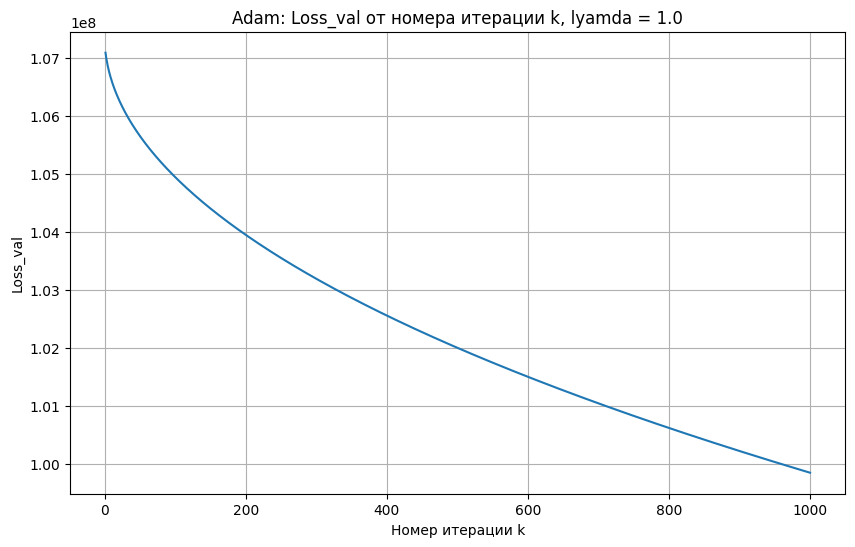

In [41]:
import matplotlib.pyplot as plt


# Результаты на train для optimal_lyamda
best_row = results_adam.loc[
    results_adam['lyamda'] == optimal_lyamda
].iloc[0]

Loss_train_optimal = best_row['Loss_train']
R2_train_optimal = best_row['R2_train']


# Обучаем Adam с optimal_lyamda
# и сохраняем Loss_val на каждой итерации k
model_optimal_adam = Adam(
    lyamda=optimal_lyamda
)

d = X_train.shape[1]

model_optimal_adam.w = np.zeros(d)

# m_0 = 0
model_optimal_adam.m = np.zeros(d)

# v_0 = 0
model_optimal_adam.v = np.zeros(d)

Loss_val_history_adam = []


for k in range(model_optimal_adam.max_iter):

    # Полный градиент MSE
    gradient = (
        2 / len(y_train)
    ) * X_train.T @ (
        X_train @ model_optimal_adam.w - y_train
    )

    # Первый момент
    model_optimal_adam.m = (
        model_optimal_adam.beta_1 * model_optimal_adam.m
        + (1 - model_optimal_adam.beta_1) * gradient
    )

    # Второй момент
    model_optimal_adam.v = (
        model_optimal_adam.beta_2 * model_optimal_adam.v
        + (1 - model_optimal_adam.beta_2) * gradient ** 2
    )

    # Коррекция смещения
    m_hat = model_optimal_adam.m / (
        1 - model_optimal_adam.beta_1 ** (k + 1)
    )

    v_hat = model_optimal_adam.v / (
        1 - model_optimal_adam.beta_2 ** (k + 1)
    )

    # TimeDecayLR
    eta_k = optimal_lyamda / np.sqrt(1 + k)

    # Изменение весов
    delta_w = (
        -eta_k
        * m_hat
        / (np.sqrt(v_hat) + model_optimal_adam.eps)
    )

    # Обновление весов
    model_optimal_adam.w += delta_w

    # Loss_val на итерации k
    y_val_pred = model_optimal_adam.predict(X_val)

    Loss_val = np.mean(
        (y_val - y_val_pred) ** 2
    )

    Loss_val_history_adam.append(Loss_val)

    # Критерий остановки
    if np.sum(delta_w ** 2) < model_optimal_adam.tolerance:
        break


# 4. Выводим результаты
print("optimal_lyamda =", optimal_lyamda)
print("Loss_train =", Loss_train_optimal)
print("Loss_test =", Loss_test_adam)
print("R2_train =", R2_train_optimal)
print("Число итераций на val =", len(Loss_val_history_adam))


# 5. График Loss_val для optimal_lyamda
# от номера итерации k
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(Loss_val_history_adam) + 1),
    Loss_val_history_adam
)

plt.xlabel("Номер итерации k")
plt.ylabel("Loss_val")

plt.title(
    f"Adam: Loss_val от номера итерации k, "
    f"lyamda = {optimal_lyamda}"
)

plt.grid(True)
plt.show()

### 18. Сравнение методов

Строим итоговую сравнительную таблицу

In [42]:
import pandas as pd


# -------------------------
# VanillaGradientDescent
# -------------------------

best_vanilla = results.loc[
    results['Loss_val'].idxmin()
]


# -------------------------
# StochasticGradientDescent
# -------------------------

best_sgd = results_sgd.loc[
    results_sgd['Loss_val'].idxmin()
]


# -------------------------
# SAGDescent
# -------------------------

best_sag = results_sag.loc[
    results_sag['Loss_val'].idxmin()
]


# -------------------------
# MomentumDescent
# -------------------------

best_momentum = results_momentum.loc[
    results_momentum['Loss_val'].idxmin()
]


# -------------------------
# Adam
# -------------------------

best_adam = results_adam.loc[
    results_adam['Loss_val'].idxmin()
]


# Итоговая сравнительная таблица

comparison_table = pd.DataFrame({

    'Метод': [
        'VanillaGradientDescent',
        'StochasticGradientDescent',
        'SAGDescent',
        'MomentumDescent',
        'Adam'
    ],

    'Лучшее λ*': [
        best_vanilla['lyamda'],
        best_sgd['lyamda'],
        best_sag['lyamda'],
        best_momentum['lyamda'],
        best_adam['lyamda']
    ],

    'Loss train': [
        best_vanilla['Loss_train'],
        best_sgd['Loss_train'],
        best_sag['Loss_train'],
        best_momentum['Loss_train'],
        best_adam['Loss_train']
    ],

    'Loss test': [
        Loss_test_vanilla,
        Loss_test_sgd,
        Loss_test_sag,
        Loss_test_momentum,
        Loss_test_adam
    ],

    'R² train': [
        best_vanilla['R2_train'],
        best_sgd['R2_train'],
        best_sag['R2_train'],
        best_momentum['R2_train'],
        best_adam['R2_train']
    ],

    'R² test': [
        R2_test_vanilla,
        R2_test_sgd,
        R2_test_sag,
        R2_test_momentum,
        R2_test_adam
    ],

    'Число итераций': [
        len(Loss_val_history),
        len(Loss_val_history_sgd),
        len(Loss_val_history_sag),
        len(Loss_val_history_momentum),
        len(Loss_val_history_adam)
    ]
})


display(comparison_table)

,Метод,Лучшее λ*,Loss train,Loss test,R² train,R² test,Число итераций
0,VanillaGradientDescent,1.00,1.486843e+07,2.552367e+07,0.755704,0.634004,1000
1,StochasticGradientDescent,0.10,1.796592e+07,3.326163e+09,0.704811,-46.695489,1000
2,SAGDescent,0.01,2.988558e+07,3.731490e+07,0.508965,0.464923,1000
3,MomentumDescent,1.00,1.251507e+07,2.807693e+07,0.794371,0.597391,1000
4,Adam,1.00,1.020001e+08,1.222102e+08,-0.675913,-0.752432,1000
